## **Load Libraries & Data**

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
print("Libraries Loaded")

Libraries Loaded


In [9]:
import pandas as pd

df = pd.read_csv(r"C:\Users\kambl\OneDrive\Desktop\loan_project\data\cleaned_data.csv")

print("Data Loaded")
print("Shape:", df.shape)
print(df.head())

Data Loaded
Shape: (150000, 13)
   id  SeriousDlqin2yrs  RevolvingUtilizationOfUnsecuredLines  age  \
0   1                 1                              0.766127   45   
1   2                 0                              0.957151   40   
2   3                 0                              0.658180   38   
3   4                 0                              0.233810   30   
4   5                 0                              0.907239   49   

   NumberOfTime30-59DaysPastDueNotWorse  DebtRatio  MonthlyIncome  \
0                                     2   0.802982         9120.0   
1                                     0   0.121876         2600.0   
2                                     1   0.085113         3042.0   
3                                     0   0.036050         3300.0   
4                                     1   0.024926        63588.0   

   NumberOfOpenCreditLinesAndLoans  NumberOfTimes90DaysLate  \
0                               13                        0   
1     

## **Feature Engineering**

In [12]:
df['debt_to_income'] = df['DebtRatio'] * df['MonthlyIncome']

df['total_late_payments'] = (
    df['NumberOfTime30-59DaysPastDueNotWorse']
    + df['NumberOfTime60-89DaysPastDueNotWorse']
    + df['NumberOfTimes90DaysLate']
)

df['high_utilization'] = (
    df['RevolvingUtilizationOfUnsecuredLines'] > 0.75
).astype(int)

print("New features created ✅")
print(df[['debt_to_income',
          'total_late_payments',
          'high_utilization']].head())

New features created ✅
   debt_to_income  total_late_payments  high_utilization
0     7323.197016                    2                 1
1      316.878123                    0                 1
2      258.914887                    2                 0
3      118.963951                    0                 0
4     1584.975094                    1                 1


## **Prepare Features & Target**

In [15]:
# Define features and target
drop_cols = ['id', 'SeriousDlqin2yrs','age_group']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
Y = df['SeriousDlqin2yrs']

print("Features.shape:", X.shape)
print("Target distribution:")
print(Y.value_counts())

Features.shape: (150000, 13)
Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64


In [18]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (120000, 13)
Test Size: (30000, 13)


## **Handle Class Imbalance with SMOTE**

In [29]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE :", pd.Series(y_train_bal).value_counts().to_dict())

Before SMOTE: {0: 111979, 1: 8021}
After SMOTE : {0: 111979, 1: 111979}


## **Scale Features**

In [20]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done ✅")

Scaling done ✅


## **Train Model 1: Logistic Regression**

In [21]:
# Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_bal)

lr_preds = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:,1]

print("=== Logistic Regression Results ===")
print(classification_report(y_test, lr_preds))
print("AUC-ROC Score:", round(roc_auc_score(y_test, lr_proba), 4))

=== Logistic Regression Results ===
              precision    recall  f1-score   support

           0       0.96      0.82      0.89     27995
           1       0.19      0.58      0.28      2005

    accuracy                           0.80     30000
   macro avg       0.58      0.70      0.59     30000
weighted avg       0.91      0.80      0.85     30000

AUC-ROC Score: 0.7642


## **Train Model 2: Random Forest**

In [22]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train_bal)

rf_preds = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:,1]

print("=== Random Forest Results ===")
print(classification_report(y_test, rf_preds))
print("AUC-ROC Score:", round(roc_auc_score(y_test, rf_proba), 4))

=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     27995
           1       0.35      0.42      0.38      2005

    accuracy                           0.91     30000
   macro avg       0.65      0.68      0.67     30000
weighted avg       0.92      0.91      0.91     30000

AUC-ROC Score: 0.835


## **Compare Both Models Visually**

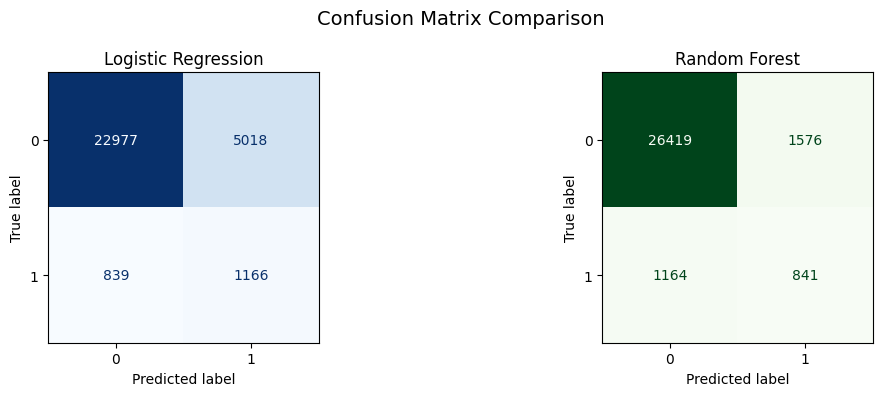

In [23]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds, ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Random Forest')

plt.suptitle('Confusion Matrix Comparison', fontsize=14)
plt.tight_layout()
plt.show()

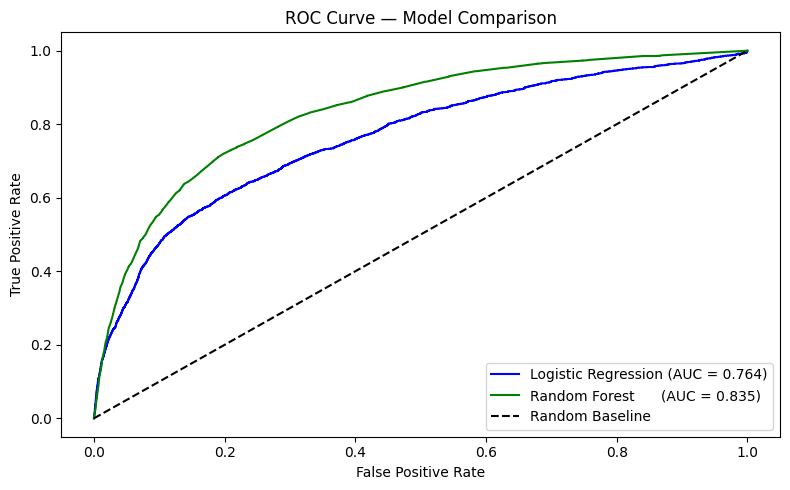

In [24]:
# ROC Curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(8,5))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, lr_proba):.3f})', color='blue')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest      (AUC = {roc_auc_score(y_test, rf_proba):.3f})', color='green')
plt.plot([0,1],[0,1], 'k--', label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## **Feature Importance**

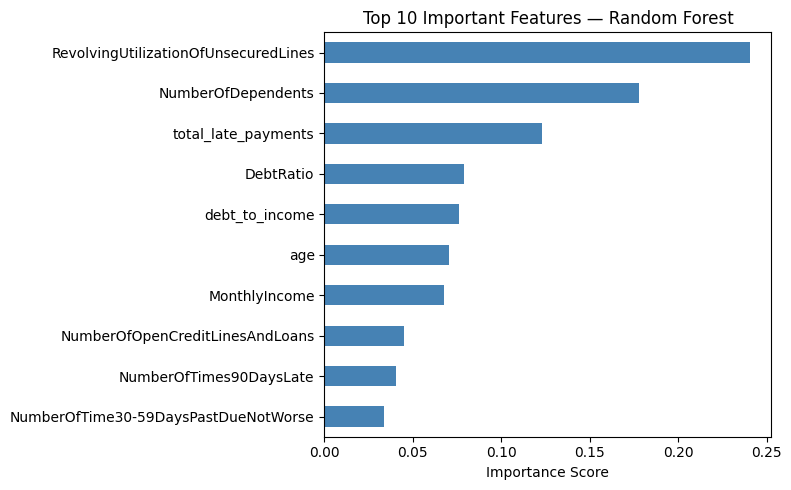

In [25]:
# Feature importance from Random Forest
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Top 10 Important Features — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## **Save Predictions for Power BI**

In [28]:
# Create final output file
results = X_test.copy()
results['actual_default']    = y_test.values
results['predicted_default'] = rf_preds
results['risk_score']        = (rf_proba * 100).round(2)  # 0-100 risk score

# Add risk category
results['risk_category'] = pd.cut(results['risk_score'],
                                   bins=[0, 30, 60, 100],
                                   labels=['Low Risk', 'Medium Risk', 'High Risk'])

# Save
output_path = r"C:\Users\kambl\OneDrive\Desktop\loan_project\output/predictions.csv"
results.to_csv(output_path, index=False)

print("Predictions saved ✅")
print("Shape:", results.shape)
print(results['risk_category'].value_counts())

Predictions saved ✅
Shape: (30000, 17)
risk_category
Low Risk       20950
Medium Risk     3807
High Risk       1553
Name: count, dtype: int64
